<p style="align: center;"><img src="https://static.tildacdn.com/tild6636-3531-4239-b465-376364646465/Deep_Learning_School.png" width="400"></p>

# Глубокое обучение. Часть 2
# Домашнее задание по теме "Механизм внимания"

Это домашнее задание проходит в формате peer-review. Это означает, что его будут проверять ваши однокурсники. Поэтому пишите разборчивый код, добавляйте комментарии и пишите выводы после проделанной работы.

В этом задании вы будете решать задачу классификации математических задач по темам (многоклассовая классификация) с помощью Transformer.

В качестве датасета возьмем датасет математических задач по разным темам. Нам необходим следующий файл:

[Файл с классами](https://docs.google.com/spreadsheets/d/13YIbphbWc62sfa-bCh8MLQWKizaXbQK9/edit?usp=drive_link&ouid=104379615679964018037&rtpof=true&sd=true)

**Hint:** не перезаписывайте модели, которые вы получите на каждом из этапов этого дз. Они ещё понадобятся.

### Задание 1 (2 балла)

Напишите кастомный класс для модели трансформера для задачи классификации, использующей в качествке backbone какую-то из моделей huggingface.

Т.е. конструктор класса должен принимать на вход название модели и подгружать её из huggingface, а затем использовать в качестве backbone (достаточно возможности использовать в качестве backbone те модели, которые упомянуты в последующих пунктах)

In [1]:

import copy
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from torch import optim
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, AutoConfig
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from tqdm import tqdm

In [2]:

class TransformerClassificationModel(nn.Module):
    def __init__(self, base_transformer_model: str, num_classes: int, dropout: float = 0.1):
        super().__init__()
        self.config = AutoConfig.from_pretrained(base_transformer_model)
        self.backbone = AutoModel.from_pretrained(base_transformer_model)

        hidden_size = self.config.hidden_size
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_size, num_classes)

    def forward(self, input_ids, attention_mask=None):
        outputs = self.backbone(input_ids=input_ids, attention_mask=attention_mask)

        pooled_output = outputs.last_hidden_state[:, 0, :]
        pooled_output = self.dropout(pooled_output)
        logits = self.classifier(pooled_output)
        return {"logits": logits}


### Задание 2 (1 балл)

Напишите функцию заморозки backbone у модели (если необходимо, возвращайте из функции модель)

In [3]:
def freeze_backbone_function(model: TransformerClassificationModel):
    for param in model.backbone.parameters():
        param.requires_grad = False
    return model

### Задание 3 (2 балла)

Напишите функцию, которая будет использована для тренировки (дообучения) трансформера (TransformerClassificationModel). Функция должна поддерживать обучение с замороженным и размороженным backbone.

In [4]:
def train_transformer(
    transformer_model,
    train_loader,
    val_loader=None,
    num_epochs=3,
    lr=2e-5,
    freeze_backbone=True
):
    model = copy.deepcopy(transformer_model)

    if freeze_backbone:
        for p in model.backbone.parameters():
            p.requires_grad = False

    device = torch.device("mps" if torch.mps.is_available() else "cpu")
    model.to(device)

    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    for epoch in range(num_epochs):
        # ---- TRAIN ----
        model.train()
        train_loss = 0
        train_preds = []
        train_labels = []

        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            input_ids = batch["input_ids"].to(device)
            labels = batch["labels"].to(device)

            optimizer.zero_grad()
            attention_mask = batch["attention_mask"].to(device)
            logits = model(input_ids=input_ids, attention_mask=attention_mask)["logits"]
            loss = loss_fn(logits, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            train_preds.extend(logits.argmax(dim=1).cpu().tolist())
            train_labels.extend(labels.cpu().tolist())

        train_acc = accuracy_score(train_labels, train_preds)
        train_f1 = f1_score(train_labels, train_preds, average="weighted")

        print(f"TRAIN | loss={train_loss/len(train_loader):.4f}, acc={train_acc:.4f}, f1={train_f1:.4f}")

        # ---- VALIDATION ----
        if val_loader is not None:
            model.eval()
            val_loss = 0
            val_preds = []
            val_labels = []

            with torch.no_grad():
                for batch in val_loader:
                    input_ids = batch["input_ids"].to(device)
                    labels = batch["labels"].to(device)

                    attention_mask = batch["attention_mask"].to(device)
                    logits = model(input_ids=input_ids, attention_mask=attention_mask)["logits"]

                    loss = loss_fn(logits, labels)
                    val_loss += loss.item()

                    val_preds.extend(logits.argmax(dim=1).cpu().tolist())
                    val_labels.extend(labels.cpu().tolist())

            val_acc = accuracy_score(val_labels, val_preds)
            val_f1 = f1_score(val_labels, val_preds, average="weighted")

            print(f"VAL   | loss={val_loss/len(val_loader):.4f}, acc={val_acc:.4f}, f1={val_f1:.4f}")

    return model



### Задание 4 (1 балл)

Проверьте вашу функцию из предыдущего пункта, дообучив двумя способами
*cointegrated/rubert-tiny2* из huggingface.

In [5]:
df = pd.read_excel("data_problems_translated.xlsx", usecols=["problem_text", "topic"])
df


,problem_text,topic
0,To prove that the sum of the numbers of the ex...,number_theory
1,( b) Will the statement of the previous challe...,number_theory
2,The quadratic three-member graph with the coef...,polynoms
3,Can you draw on the surface of Rubik's cube a ...,combinatorics
4,"Dima, who came from Vrunlandia, said that ther...",graphs
...,...,...
5268,Can the number n! end with the figures of 76.0...,number_theory
5269,Find all natural m and n for which m! + 12 = n2.,number_theory
5270,"The correct 5,000-column has a 2001 vertebrate...",dirichlet
5271,Find the maximum number N for which there are ...,number_theory


In [6]:
# Очистка датасета от NaN и не-строковых значений
print(f"Размер датасета до очистки: {len(df)}")
df = df.dropna(subset=['problem_text'])  # Удаляем строки с NaN
df = df[df['problem_text'].apply(lambda x: isinstance(x, str))]  # Оставляем только строки
print(f"Размер датасета после очистки: {len(df)}")

Размер датасета до очистки: 5273
Размер датасета после очистки: 5268


In [9]:
train_df, val_df = train_test_split(
    df,
    test_size=0.15,
    random_state=42,
    stratify=df["topic"] # чтобы не было перекосов
)

In [10]:
label2id = {label: i for i, label in enumerate(sorted(set(df["topic"])))}
id2label = {v: k for k, v in label2id.items()}
num_classes = len(label2id)

In [11]:
class MathProblemsDataset(Dataset):
    def __init__(self, dataframe, tokenizer, label2id, max_len=128, device="cpu"):
        self.data = dataframe
        self.tokenizer = tokenizer
        self.label2id = label2id
        self.max_len = max_len
        self.device = device

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        text = row["problem_text"]

        if not isinstance(text, str):
            print("БИТАЯ СТРОКА:", idx, type(text), text)
            raise ValueError("Text is not string")

        label = self.label2id[row["topic"]]

        encoded = self.tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=self.max_len,
            return_tensors="pt",
        )

        input_ids = encoded["input_ids"].squeeze(0).to(self.device)
        attention_mask = encoded["attention_mask"].squeeze(0).to(self.device)

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "labels": torch.tensor(label, dtype=torch.long).to(self.device),
        }

    def __len__(self):
        return len(self.data)


In [12]:
tokenizer = AutoTokenizer.from_pretrained("cointegrated/rubert-tiny2")

In [13]:
train_dataset = MathProblemsDataset(train_df, tokenizer, label2id, device="mps" if torch.mps.is_available() else "cpu")
val_dataset   = MathProblemsDataset(val_df,   tokenizer, label2id, device="mps" if torch.mps.is_available() else "cpu")

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=8, shuffle=False)


print(f"Train Dataset: {len(train_dataset)} examples, {num_classes} classes")
print(f"Val Dataset: {len(val_dataset)} examples, {num_classes} classes")

Train Dataset: 4477 examples, 7 classes
Val Dataset: 791 examples, 7 classes


In [14]:
base_model_name = "cointegrated/rubert-tiny2"
num_classes = len(label2id)

print(f"Training MODEL {base_model_name} with freeze backbone")

model_frozen = TransformerClassificationModel(
    base_transformer_model=base_model_name,
    num_classes=num_classes
)
rubert_tiny_finetuned_with_freezed_backbone = train_transformer(
    transformer_model=model_frozen,
    train_loader=train_loader,
    val_loader=val_loader,
    freeze_backbone=True
)


print(f"\n\nTraining fully MODEL {base_model_name}")

model_full = TransformerClassificationModel(
    base_transformer_model=base_model_name,
    num_classes=num_classes
)
rubert_tiny_full_finetuned = train_transformer(
    transformer_model=model_full,
    train_loader=train_loader,
    val_loader=val_loader,
    freeze_backbone=False
)


Training MODEL cointegrated/rubert-tiny2 with freeze backbone


Epoch 1/3: 100%|██████████| 560/560 [00:09<00:00, 57.61it/s]


TRAIN | loss=1.8132, acc=0.2772, f1=0.2717
VAL   | loss=1.6647, acc=0.4210, f1=0.3192


Epoch 2/3: 100%|██████████| 560/560 [00:12<00:00, 44.52it/s]


TRAIN | loss=1.6136, acc=0.4322, f1=0.3075
VAL   | loss=1.5486, acc=0.4513, f1=0.2946


...

TRAIN | loss=1.3016, acc=0.5238, f1=0.4467
VAL   | loss=1.0658, acc=0.5980, f1=0.5391


Epoch 2/3: 100%|██████████| 560/560 [00:19<00:00, 29.04it/s]


TRAIN | loss=1.0289, acc=0.6156, f1=0.5706
VAL   | loss=0.9764, acc=0.6296, f1=0.6040


Epoch 3/3: 100%|██████████| 560/560 [00:19<00:00, 29.04it/s]


TRAIN | loss=0.9069, acc=0.6480, f1=0.6167
VAL   | loss=0.9666, acc=0.6005, f1=0.5887


### Задание 5 (1 балл)

Обучите *tbs17/MathBert* (с замороженным backbone и без заморозки), проанализируйте результаты. Сравните скоры с первым заданием. Получилось лучше или нет? Почему?

In [15]:
from transformers import DataCollatorWithPadding, AutoTokenizer


base_model_name = "tbs17/MathBERT"

tokenizer = AutoTokenizer.from_pretrained(base_model_name)

train_dataset = MathProblemsDataset(train_df, tokenizer, label2id, device="cuda" if torch.cuda.is_available() else "cpu")
val_dataset   = MathProblemsDataset(val_df,   tokenizer, label2id, device="cuda" if torch.cuda.is_available() else "cpu")

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=8, shuffle=False)


print(f"Training MODEL {base_model_name} with freeze backbone")
mathbert_model = TransformerClassificationModel(base_model_name, num_classes)
mathbert_finetuned_freezed = train_transformer(
    mathbert_model,
    train_loader=train_loader,
    val_loader=val_loader,
    freeze_backbone=True
)

print(f"\n\nTraining fully MODEL {base_model_name}")
mathbert_finetuned_full = train_transformer(
    mathbert_model,
    train_loader=train_loader,
    val_loader=val_loader,
    freeze_backbone=False
)

Training MODEL tbs17/MathBERT with freeze backbone


Epoch 1/3: 100%|██████████| 560/560 [00:35<00:00, 15.81it/s]


TRAIN | loss=1.7170, acc=0.3732, f1=0.3060
VAL   | loss=1.5764, acc=0.4437, f1=0.2970


Epoch 2/3: 100%|██████████| 560/560 [00:34<00:00, 16.28it/s]


TRAIN | loss=1.5593, acc=0.4427, f1=0.3275
VAL   | loss=1.5083, acc=0.4576, f1=0.3270


...

TRAIN | loss=1.1605, acc=0.5700, f1=0.5279
VAL   | loss=1.0170, acc=0.5803, f1=0.5691


Epoch 2/3: 100%|██████████| 560/560 [01:59<00:00,  4.67it/s]


TRAIN | loss=0.8532, acc=0.6598, f1=0.6403
VAL   | loss=1.0502, acc=0.5980, f1=0.5637


Epoch 3/3: 100%|██████████| 560/560 [01:59<00:00,  4.68it/s]


TRAIN | loss=0.6807, acc=0.7244, f1=0.7156
VAL   | loss=1.0833, acc=0.5525, f1=0.5514


Выглядит немного хуже(max acc на второй эпохе на валидации - 0.6182 в то время как для первой модели 0.63), что нелогично. Думали что мат модели будут лучше различать. С другой стороны видно что обе модели не очень хороши

### Задание 6 (1 балл)

Напишите функцию для отрисовки карт внимания первого слоя для моделей из задания

In [ ]:
def draw_first_layer_attention_maps(attention_head_ids: List, text: str, model: TransformerClassificationModel):

  model.eval()

  tokenizer = AutoTokenizer.from_pretrained(model.backbone.name_or_path)

  encoded = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=64)

  with torch.no_grad():

    encoded["input_ids"] = encoded["input_ids"].to(model.backbone.device)
    encoded["attention_mask"] = encoded["attention_mask"].to(model.backbone.device)
    outputs = model.backbone(input_ids=encoded["input_ids"], attention_mask=encoded["attention_mask"], output_attentions=True)

  first_layer_attention = outputs.attentions[0][0]  # [num_heads, seq_len, seq_len]

  tokens = tokenizer.convert_ids_to_tokens(encoded["input_ids"][0])

  # убираем спецтокены
  cleaned_tokens = []
  keep_indexes = []
  for i, tok in enumerate(tokens):
    if tok not in ["[CLS]", "[SEP]", "[PAD]"]:
      cleaned_tokens.append(tok)
      keep_indexes.append(i)

  keep_indexes = torch.tensor(keep_indexes)


  num_heads_to_show = len(attention_head_ids)
  plt.figure(figsize=(6 * num_heads_to_show, 5))

  for i, head_id in enumerate(attention_head_ids):
    # берём только строки/столбцы не-спец-токенов
    attn = first_layer_attention[head_id]
    attn = attn[keep_indexes][:, keep_indexes]  # фильтрация
    attn_matrix = attn.cpu().numpy()

    plt.subplot(1, num_heads_to_show, i + 1)
    sns.heatmap(attn_matrix,xticklabels=cleaned_tokens,yticklabels=cleaned_tokens,cmap="viridis")
    plt.title(f"Head {head_id} — Layer 1")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)

  plt.tight_layout()
  plt.show()

### Задание 7 (1 балл)

Проведите инференс для всех моделей **ДО ДООБУЧЕНИЯ** на 2-3 текстах из датасета. Посмотрите на головы Attention первого слоя в каждой модели на выбранных текстах (отрисуйте их отдельно).

Попробуйте их проинтерпретировать. Какие связи улавливают карты внимания? (если в модели много голов Attention, то проинтерпретируйте наиболее интересные)


======================== TEXT 1 ========================
To prove that the sum of the numbers of the exact square cannot be equal to 5.

--- RuBERT-tiny2 (до обучения) ---


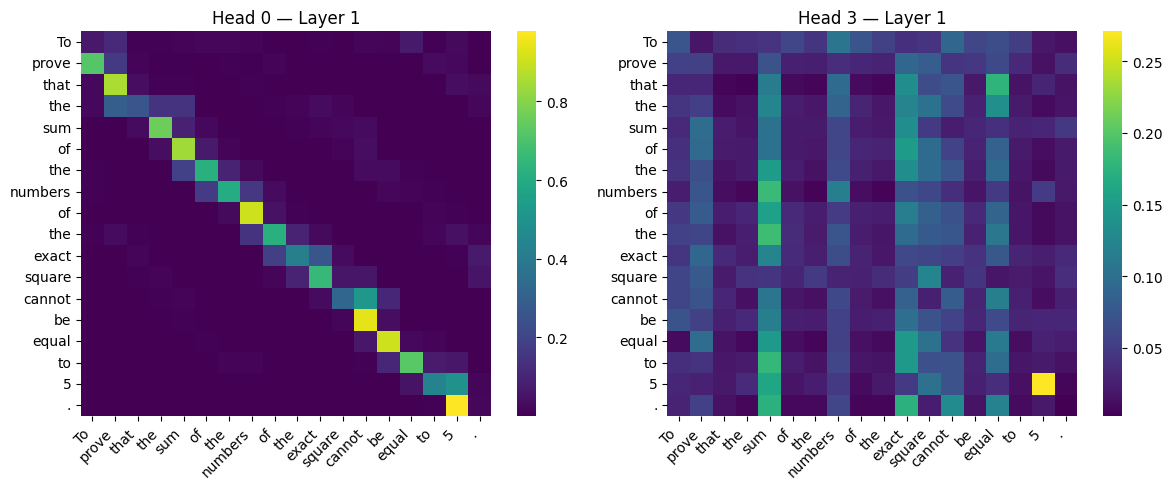


--- MathBERT (до обучения) ---


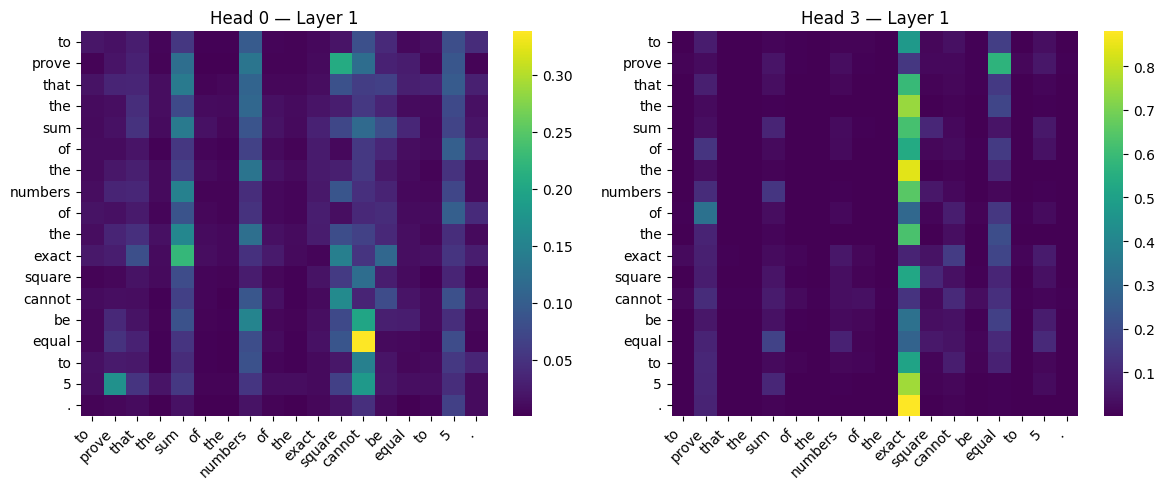


======================== TEXT 2 ========================
( b) Will the statement of the previous challenge remain true if Petia and Wasa originally planned four natural numbers?

--- RuBERT-tiny2 (до обучения) ---


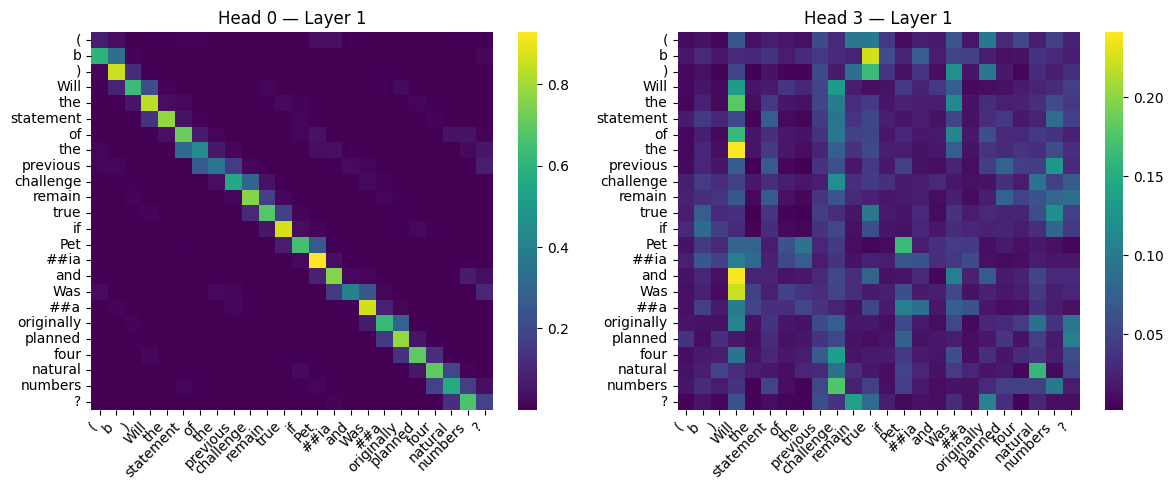


--- MathBERT (до обучения) ---


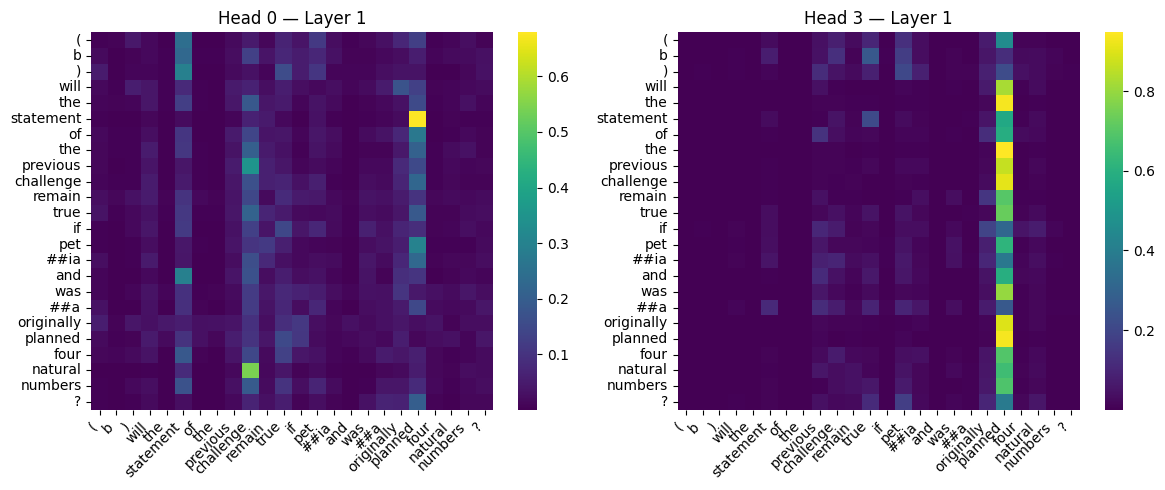

In [ ]:
sample_texts = [
    df.iloc[0]["problem_text"],
    df.iloc[1]["problem_text"],
]

rubert_base = TransformerClassificationModel("cointegrated/rubert-tiny2", num_classes)
mathbert_base = TransformerClassificationModel("tbs17/MathBERT", num_classes)

heads = [0, 3]  # пару голов для просмотра

for idx, text in enumerate(sample_texts):
    print(f"\n======================== TEXT {idx+1} ========================")
    print(text)

    print("\n--- RuBERT-tiny2 (до обучения) ---")
    draw_first_layer_attention_maps(heads, text, rubert_base)

    print("\n--- MathBERT (до обучения) ---")
    draw_first_layer_attention_maps(heads, text, mathbert_base)


Первая голова смотрит на себя и соседние слова. третья уже пытается уловить какие-то связи

### Задание 8 (1 балл)

Сделайте то же самое для дообученных моделей. Изменились ли карты внимания и связи, которые они улавливают? Почему?


======================== TEXT 1 ========================
To prove that the sum of the numbers of the exact square cannot be equal to 5.

--- RuBERT-tiny2 (полный файнтюн) ---


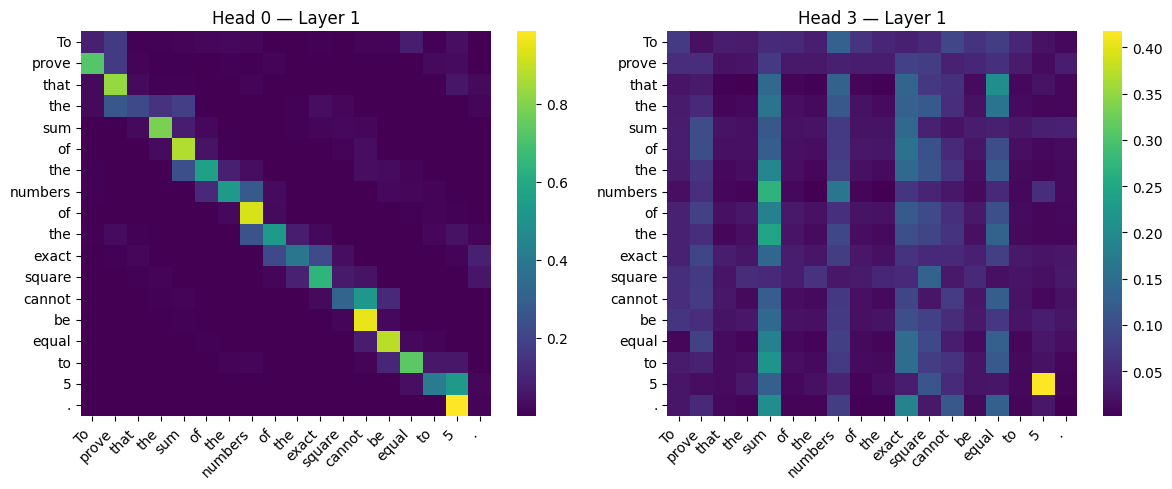


--- MathBERT (полный файнтюн) ---


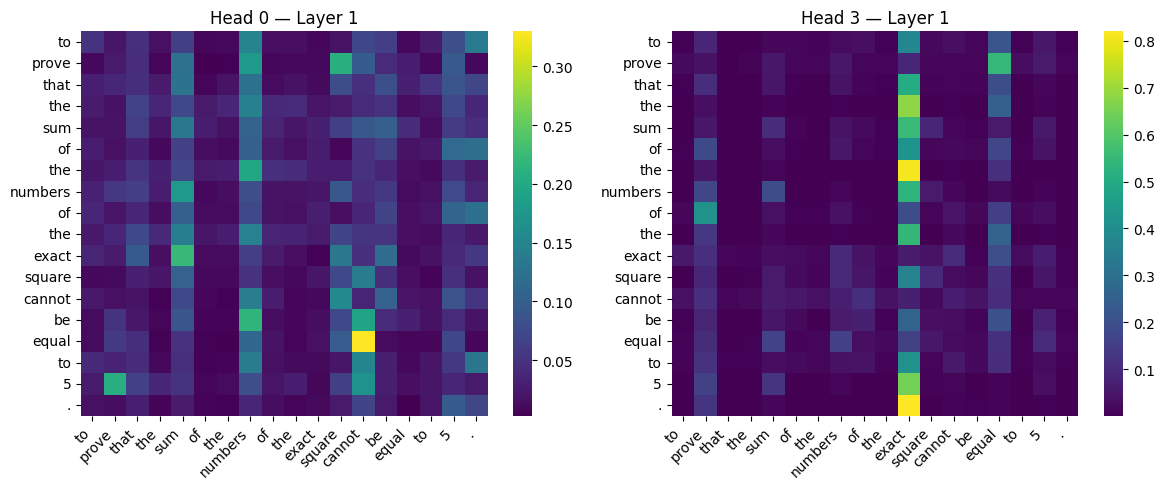


======================== TEXT 2 ========================
( b) Will the statement of the previous challenge remain true if Petia and Wasa originally planned four natural numbers?

--- RuBERT-tiny2 (полный файнтюн) ---


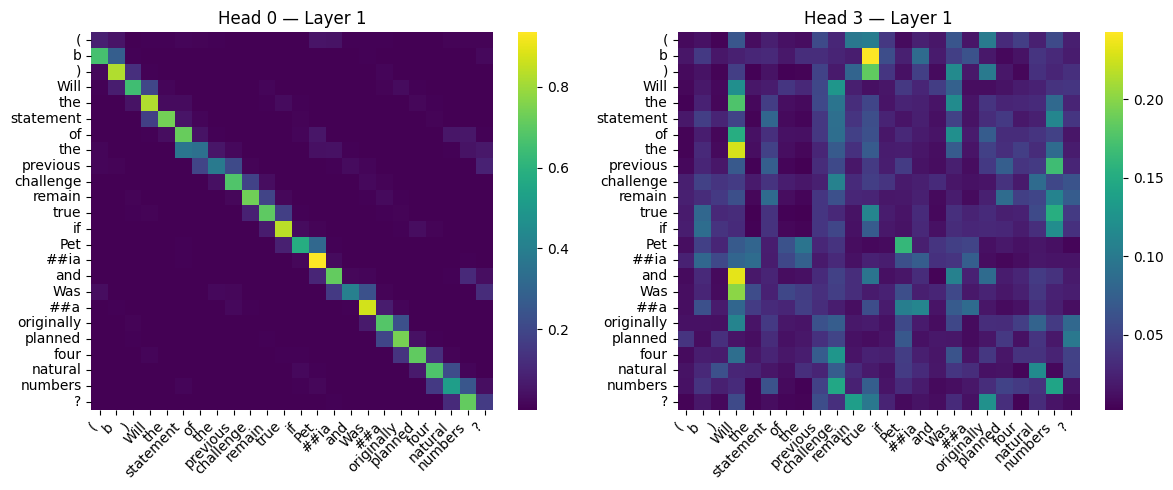


--- MathBERT (полный файнтюн) ---


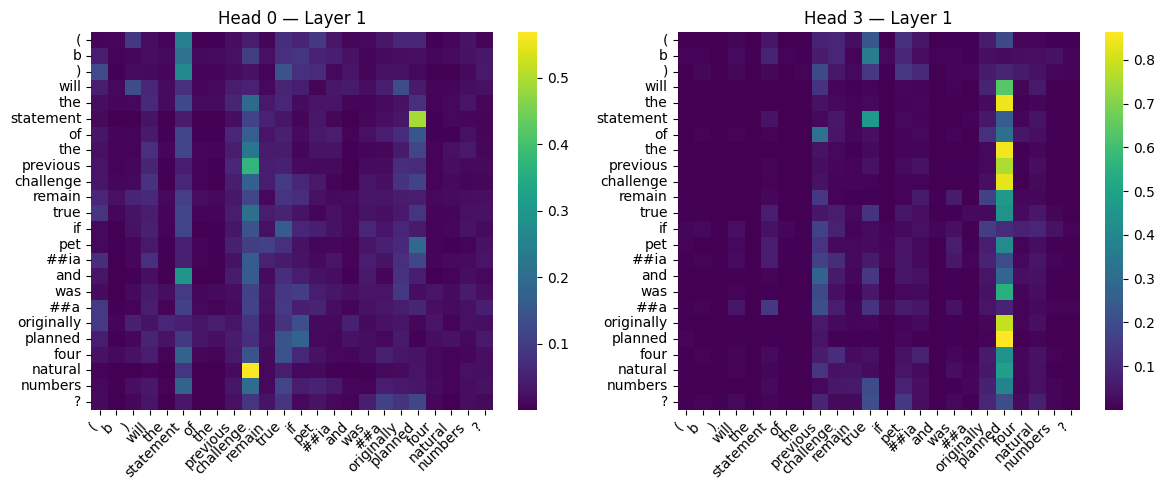

In [ ]:
sample_texts = [
    df.iloc[0]["problem_text"],
    df.iloc[1]["problem_text"],
]

heads = [0, 3]  # пару голов для просмотра

for idx, text in enumerate(sample_texts):
    print(f"\n======================== TEXT {idx+1} ========================")
    print(text)

    print("\n--- RuBERT-tiny2 (полный файнтюн) ---")
    draw_first_layer_attention_maps(heads, text, rubert_tiny_full_finetuned)

    print("\n--- MathBERT (полный файнтюн) ---")
    draw_first_layer_attention_maps(heads, text, mathbert_finetuned_full)

Особо не видно разницы, гипотеза что не сильно что-то поменялось за 3 эпохи в первом слое